# Challenge Alura Store Latam

### Importación de datos

In [99]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


Exploración de datos

In [100]:
for i, df in enumerate([tienda, tienda2, tienda3, tienda4], start=1):
    print(f"=== TIENDA {i} ===")
    print(df.info())
    print(df.describe())
    print("\nPrimeras filas:")
    print(df.head(), "\n\n")

=== TIENDA 1 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB
None
             Precio  Costo de envío  Calificación  Cantidad de cu

#1. Análisis de facturación



In [101]:
# Cálculo del ingreso total por tienda
ingreso_tienda = tienda['Precio'].sum()
ingreso_tienda2 = tienda2['Precio'].sum()
ingreso_tienda3 = tienda3['Precio'].sum()
ingreso_tienda4 = tienda4['Precio'].sum()


    # Mostrar resultados
print(f"Ingreso total Tienda 1: ${ingreso_tienda:,.2f}")
print(f"Ingreso total Tienda 2: ${ingreso_tienda2:,.2f}")
print(f"Ingreso total Tienda 3: ${ingreso_tienda3:,.2f}")
print(f"Ingreso total Tienda 4: ${ingreso_tienda4:,.2f}")

Ingreso total Tienda 1: $1,150,880,400.00
Ingreso total Tienda 2: $1,116,343,500.00
Ingreso total Tienda 3: $1,098,019,600.00
Ingreso total Tienda 4: $1,038,375,700.00


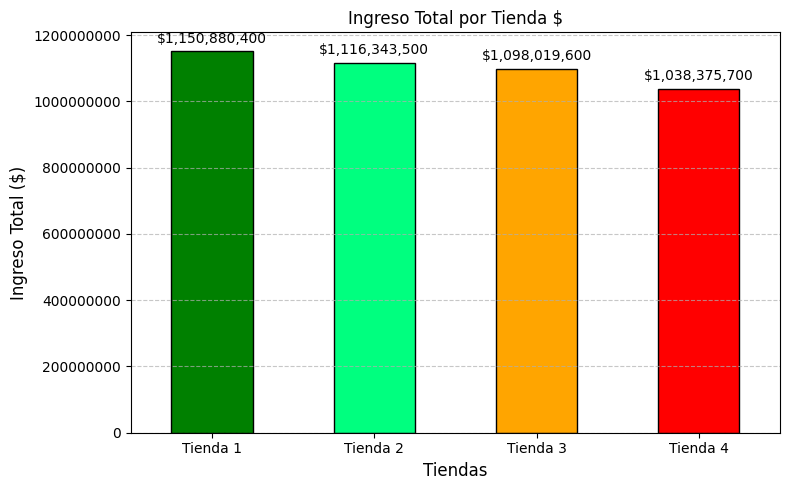

In [102]:
import matplotlib.pyplot as plt
import pandas as pd

# Datos
ingresos_totales = {
    "Tienda 1": ingreso_tienda,
    "Tienda 2": ingreso_tienda2,
    "Tienda 3": ingreso_tienda3,
    "Tienda 4": ingreso_tienda4
}

# Gráfico de Barras

ingresos_series = pd.Series(ingresos_totales)
plt.figure(figsize=(8, 5))
ax = ingresos_series.plot(kind='bar', color=['green', 'springgreen', 'orange', 'red'], edgecolor='black')
plt.title('Ingreso Total por Tienda $')
plt.xlabel('Tiendas', fontsize=12)
plt.ylabel("Ingreso Total ($)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)
plt.tight_layout()
plt.show()

# 2. Ventas por categoría

In [103]:
print("Qué tipo de productos se venden más en cada tienda:\n")

print("\nLas 3 categorías con más ventas en la Tienda 1 fueron:")
cat1 = tienda['Categoría del Producto'].value_counts().head(3)
for i, (cat, cant) in enumerate(cat1.items(), 1):
    print(f"  {i}. {cat}: {cant} productos")

print("\nLas 3 categorías con más ventas en la Tienda 2 fueron:")
cat2 = tienda2['Categoría del Producto'].value_counts().head(3)
for i, (cat, cant) in enumerate(cat2.items(), 1):
    print(f"  {i}. {cat}: {cant} productos")

print("\nLas 3 categorías con más ventas en la Tienda 3 fueron:")
cat3 = tienda3['Categoría del Producto'].value_counts().head(3)
for i, (cat, cant) in enumerate(cat3.items(), 1):
    print(f"  {i}. {cat}: {cant} productos")

print("\nLas 3 categorías con más ventas en la Tienda 4 fueron:")
cat4 = tienda4['Categoría del Producto'].value_counts().head(3)
for i, (cat, cant) in enumerate(cat4.items(), 1):
    print(f"  {i}. {cat}: {cant} productos")

Qué tipo de productos se venden más en cada tienda:


Las 3 categorías con más ventas en la Tienda 1 fueron:
  1. Muebles: 465 productos
  2. Electrónicos: 448 productos
  3. Juguetes: 324 productos

Las 3 categorías con más ventas en la Tienda 2 fueron:
  1. Muebles: 442 productos
  2. Electrónicos: 422 productos
  3. Juguetes: 313 productos

Las 3 categorías con más ventas en la Tienda 3 fueron:
  1. Muebles: 499 productos
  2. Electrónicos: 451 productos
  3. Juguetes: 315 productos

Las 3 categorías con más ventas en la Tienda 4 fueron:
  1. Muebles: 480 productos
  2. Electrónicos: 451 productos
  3. Juguetes: 338 productos


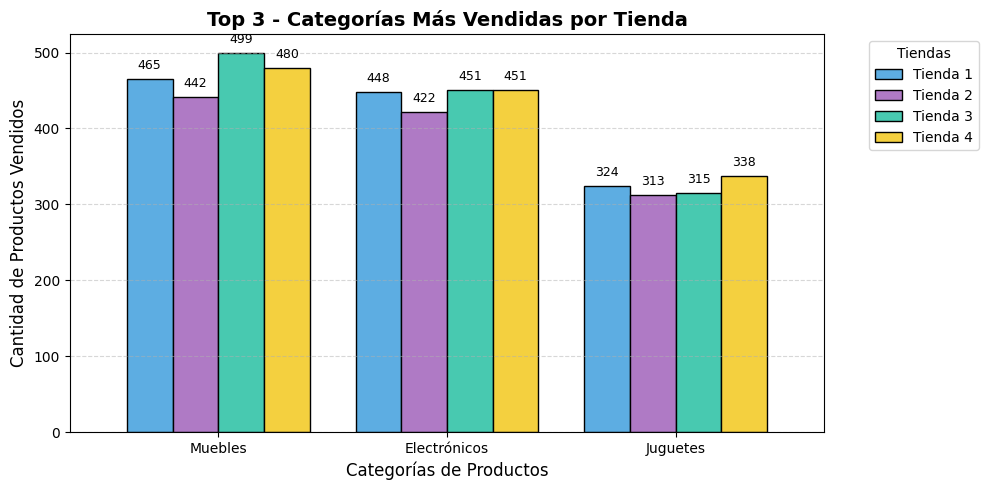

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

data_grafica = {
    "Tienda 1": tienda['Categoría del Producto'].value_counts().head(3),
    "Tienda 2": tienda2['Categoría del Producto'].value_counts().head(3),
    "Tienda 3": tienda3['Categoría del Producto'].value_counts().head(3),
    "Tienda 4": tienda4['Categoría del Producto'].value_counts().head(3)
}

df_ventas = pd.DataFrame(data_grafica).fillna(0)

colores = ['#5DADE2', '#AF7AC5', '#48C9B0', '#F4D03F']

ax = df_ventas.plot(kind='bar', figsize=(10, 5), color=colores, edgecolor='black', width=0.8)

plt.title('Top 3 - Categorías Más Vendidas por Tienda', fontsize=14, fontweight='bold')
plt.xlabel('Categorías de Productos', fontsize=12)
plt.ylabel('Cantidad de Productos Vendidos', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Tiendas", bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [108]:
# Calcular promedio de calificaciones por tienda
promedio_t1 = tienda['Calificación'].mean()
promedio_t2 = tienda2['Calificación'].mean()
promedio_t3 = tienda3['Calificación'].mean()
promedio_t4 = tienda4['Calificación'].mean()

# Mostrar resultados
print(f"Calificación promedio Tienda 1: {promedio_t1:.2f}")
print(f"Calificación promedio Tienda 2: {promedio_t2:.2f}")
print(f"Calificación promedio Tienda 3: {promedio_t3:.2f}")
print(f"Calificación promedio Tienda 4: {promedio_t4:.2f}")

Calificación promedio Tienda 1: 3.98
Calificación promedio Tienda 2: 4.04
Calificación promedio Tienda 3: 4.05
Calificación promedio Tienda 4: 4.00


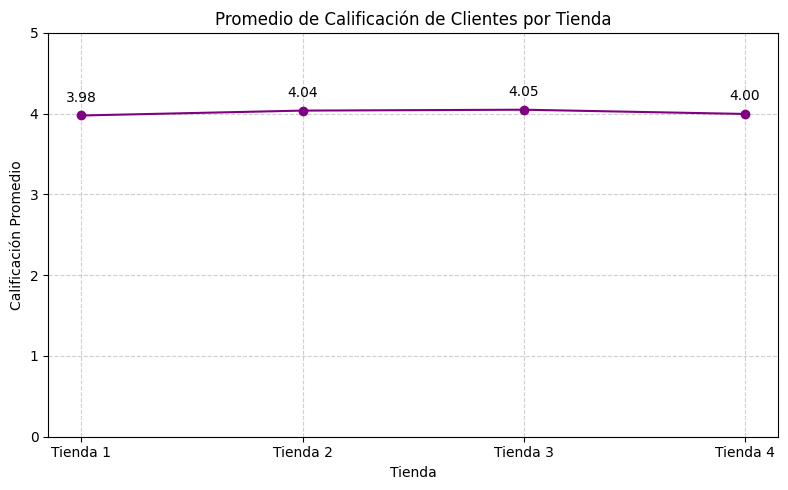

In [111]:
import matplotlib.pyplot as plt
import pandas as pd

# Datos de calificaciones promedio por tienda
calificaciones_promedio = {
    "Tienda 1": promedio_t1,
    "Tienda 2": promedio_t2,
    "Tienda 3": promedio_t3,
    "Tienda 4": promedio_t4
}

# Crear una Serie de Pandas para facilitar el trazado
calificaciones_series = pd.Series(calificaciones_promedio)

# Crear el gráfico lineal
plt.figure(figsize=(8, 5))
ax = plt.gca() # Obtener los ejes actuales

# Plotear los valores numéricos contra índices numéricos
ax.plot(range(len(calificaciones_series)), calificaciones_series.values, marker='o', color='purple', linestyle='-')

# Establecer los ticks y etiquetas del eje X
ax.set_xticks(range(len(calificaciones_series)))
ax.set_xticklabels(calificaciones_series.index)

# Añadir título y etiquetas
plt.title('Promedio de Calificación de Clientes por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Calificación Promedio')

# Añadir valores a cada punto en el gráfico
for i, (tienda_nombre, calificacion) in enumerate(calificaciones_promedio.items()):
    ax.annotate(f'{calificacion:.2f}', (i, calificacion), textcoords="offset points", xytext=(0,10), ha='center')

plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 5) # Las calificaciones suelen ir de 1 a 5
plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

In [106]:
print("Los Productos más y menos vendidos por tienda son:\n")

tiendas_data = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

for nombre_tienda, df_tienda in tiendas_data.items():
    top = df_tienda['Producto'].value_counts().head(1)
    low = df_tienda['Producto'].value_counts().tail(1)
    print(f"{nombre_tienda}:")
    print(f"El producto más vendido es: {top.index[0]} con {top.values[0]} unidades vendidas")
    print(f"El producto menos vendido es: {low.index[0]} con {low.values[0]} unidades vendidas\n")

Los Productos más y menos vendidos por tienda son:

Tienda 1:
El producto más vendido es: Microondas con 60 unidades vendidas
El producto menos vendido es: Celular ABXY con 33 unidades vendidas

Tienda 2:
El producto más vendido es: Iniciando en programación con 65 unidades vendidas
El producto menos vendido es: Juego de mesa con 32 unidades vendidas

Tienda 3:
El producto más vendido es: Kit de bancas con 57 unidades vendidas
El producto menos vendido es: Bloques de construcción con 35 unidades vendidas

Tienda 4:
El producto más vendido es: Cama box con 62 unidades vendidas
El producto menos vendido es: Guitarra eléctrica con 33 unidades vendidas



# 5. Envío promedio por tienda

In [107]:
envios = {
    'Tienda 1': tiendas_data['Tienda 1']['Costo de envío'].mean(),
    'Tienda 2': tiendas_data['Tienda 2']['Costo de envío'].mean(),
    'Tienda 3': tiendas_data['Tienda 3']['Costo de envío'].mean(),
    'Tienda 4': tiendas_data['Tienda 4']['Costo de envío'].mean()
}

for nombre_tienda, envio_promedio in envios.items():
    print(f"{nombre_tienda}: ${envio_promedio:,.0f} en promedio")

Tienda 1: $26,019 en promedio
Tienda 2: $25,216 en promedio
Tienda 3: $24,806 en promedio
Tienda 4: $23,459 en promedio


Conforme a la solicitud realizada, se analizó el rendimiento de sus cuatro tiendas, encontramos los siguientes resultados generales:


1. La Tienda 1 es la que genera los mayores ingresos ($1,150,880,400), aunque sus clientes son los menos satisfechos (3.98) y el envío es el más costoso.

2. La Tienda 2 es la que mantiene un desempeño estable, con buenos ingresos ($1,116,343,500), una calificación positiva (4.04) y costos de envío moderados.

3. La Tienda 3 es la que tiene la mejor calificación de clientes (4.05), buenos ingresos ($1,098,019,600) y un envío es competitivo; representa el equilibrio ideal entre ventas y satisfacción.

4. La Tienda 4 es la que genera menos ingresos ($1,038,375,700) y ofrece los envíos más baratos, reduciendo su margen de ganancia.

En conjunto, sus tiendas muestran un negocio sólido, pero la Tienda 4 es que la genera menos ingresos.

La recomendación es que venda la Tienda 4, ya que presenta los menores ingresos y menor ganancia por envío. Esto le permitirá tener capital para invertir en las tiendas que si tienen mejores ingresos o aperturar más tiendas en otros sectores competitivos.


La conclusión sería que las tiendas tienen un rendimiento positivo en general, pero los datos muestran que la Tienda 4 es la menos rentable. Venderla le dará la oportunidad de expandirse a nuevos sectores y/o expandir su inventario en las tiendas que tienen las mejores ventas.